<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/23_imputing_numerical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [24]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/titanic_toy.csv")

In [25]:
df.head(4)

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1


In [26]:
X=df.iloc[:,0:3]
y=df.iloc[:,-1]

In [27]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=42)

In [34]:
X_train["Age_mean"] = X_train["Age"].fillna(X_train["Age"].mean())
X_train["Age_median"] = X_train["Age"].fillna(X_train["Age"].median())

X_train["Fare_mean"] = X_train["Fare"].fillna(X_train["Fare"].mean())
X_train["Fare_median"] = X_train["Fare"].fillna(X_train["Fare"].median())

In [35]:
print("Orinal Age", X_train["Age"].var())
print("After Mean Age", X_train["Age_mean"].var())
print("After Median Age", X_train["Age_median"].var())

print("Orinal Fare", X_train["Fare"].var())
print("After Mean fare", X_train["Fare_mean"].var())
print("After Median fare", X_train["Fare_median"].var())


Orinal Age 210.2517072477438
After Mean Age 168.8519336687225
After Median Age 169.20731007048096
Orinal Fare 2761.031434948639
After Mean fare 2621.2323749512393
After Median fare 2637.01248167777


<Axes: ylabel='Density'>

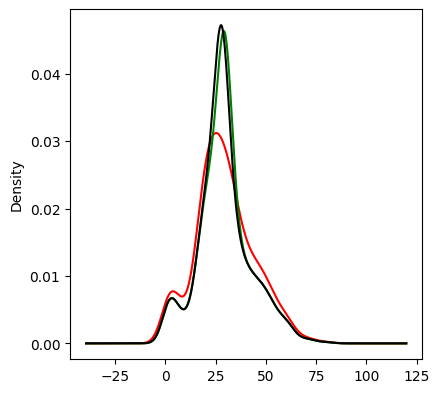

In [44]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222)

X_train["Age"].plot.density(ax=ax, color="red")
X_train["Age_mean"].plot.density(ax=ax, color="green")
X_train["Age_median"].plot.density(ax=ax, color="black")




<Axes: ylabel='Density'>

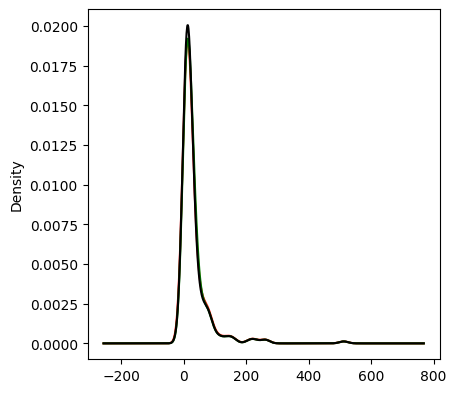

In [45]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222)

X_train["Fare"].plot.density(ax=ax, color="red")
X_train["Fare_mean"].plot.density(ax=ax, color="green")
X_train["Fare_median"].plot.density(ax=ax, color="black")




<Axes: ylabel='Density'>

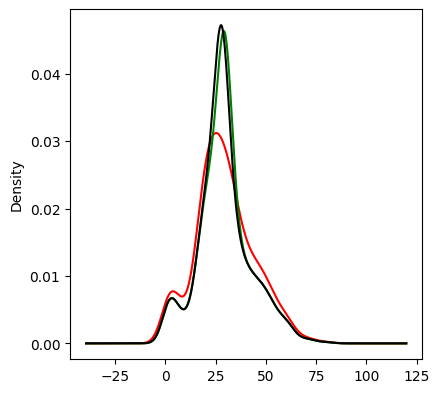

In [47]:
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(222)

X_train["Age"].plot(kind="kde",ax=ax, color="red")
X_train["Age_mean"].plot(kind="kde",ax=ax, color="green")
X_train["Age_median"].plot(kind="kde",ax=ax, color="black")




# New section

In [56]:
column_tranfer=ColumnTransformer([
    ("trf1", SimpleImputer(strategy="mean"), ["Age"]),
    ("trf2", SimpleImputer(strategy="median"), ["Fare"])
], remainder="passthrough")

In [58]:
X_train_trf=column_tranfer.fit_transform(X_train)
X_test_trf=column_tranfer.fit_transform(X_test)

In [66]:
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
Age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
Age_median,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
Fare_mean,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
Fare_median,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [67]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
Age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
Age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
Fare_mean,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
Fare_median,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


<Axes: >

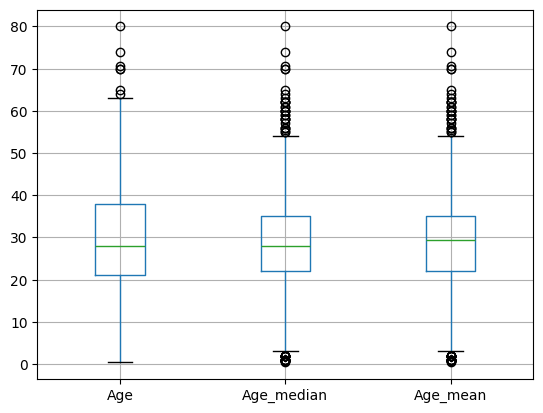

In [68]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

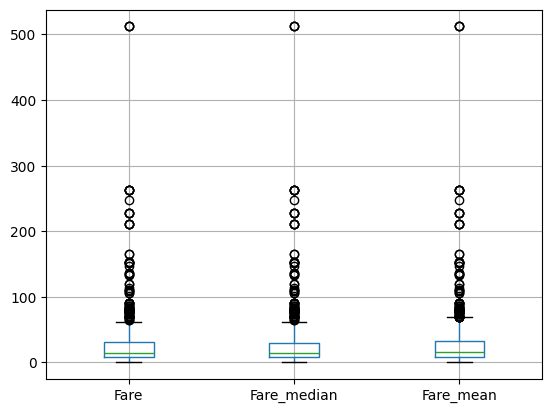

In [69]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

**arbitrary-value-imputation**

In [96]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [112]:
column_tranfer=ColumnTransformer([
    ("trf1", SimpleImputer(strategy="constant", fill_value=99), ["Age"]),
    ("trf2", SimpleImputer(strategy="constant",fill_value=99), ["Fare"])
], remainder="passthrough")

In [113]:
X_trans_trf22=column_tranfer.fit_transform(X_train)
X_test_trf222=column_tranfer.transform(X_test)

In [114]:
X_train.shape

(712, 3)

In [115]:
X_trans_trf22.shape

(712, 3)

In [116]:
X_train["Age_mean"] = X_train["Age"].fillna(99)
X_train["Age_median"] = X_train["Age"].fillna(40)

X_train["Fare_mean"] = X_train["Fare"].fillna(50)
X_train["Fare_median"] = X_train["Fare"].fillna(40)

In [117]:
X_train

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
331,45.5,28.5000,0,45.5,45.5,28.5000,28.5000
733,23.0,13.0000,0,23.0,23.0,13.0000,13.0000
382,32.0,7.9250,0,32.0,32.0,7.9250,7.9250
704,26.0,7.8542,1,26.0,26.0,7.8542,7.8542
813,6.0,31.2750,6,6.0,6.0,31.2750,31.2750
...,...,...,...,...,...,...,...
106,21.0,7.6500,0,21.0,21.0,7.6500,7.6500
270,NaN,31.0000,0,99.0,40.0,31.0000,31.0000
860,41.0,NaN,2,41.0,41.0,50.0000,40.0000
435,14.0,120.0000,3,14.0,14.0,120.0000,120.0000


**End of disctrubution**